## Paso 1. 

### Cargar y preparar datos

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ver todas las columnas

pd.set_option('display.max_columns', None)

# Cargar los 3 datasets

visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs  = pd.read_csv('/datasets/costs_us.csv')

#Vista de cada tabla

visits.head()
orders.head()
costs.head()


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


### 1.1. Tipos de datos y limpieza

In [254]:
# Renombrar columnas

visits = visits.rename(columns={
    'Uid': 'uid',
    'Device': 'device',
    'Start Ts': 'start_ts',
    'End Ts': 'end_ts',
    'Source Id': 'source_id'
})

orders = orders.rename(columns={
    'Uid': 'uid',
    'Buy Ts': 'buy_ts',
    'Revenue': 'revenue'
})

# Convertir a datetime

visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts']   = pd.to_datetime(visits['end_ts'])

orders['buy_ts']   = pd.to_datetime(orders['buy_ts'])
costs['dt']        = pd.to_datetime(costs['dt'])

### 1.2. Crear columnas derivadas para análisis

In [255]:
# en visits
visits['date']  = visits['start_ts'].dt.date
visits['month'] = visits['start_ts'].dt.to_period('M')

# duración de la sesión en minutos
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds() / 60

# en orders
orders['date']  = orders['buy_ts'].dt.date
orders['month'] = orders['buy_ts'].dt.to_period('M')


#### Carga y preparación de los datos

En este paso se cargaron los tres archivos proporcionados (`visits_log_us.csv`, `orders_log_us.csv` y `costs_us.csv`). 

- Se estandarizaron los nombres de las columnas;
- Se convirtieron las columnas de fecha y hora al tipo `datetime`;
- Se revisaron nulos y duplicados;
- Se crearon columnas auxiliares (`date`, `month`, `session_duration`) para facilitar el análisis posterior.


## Paso 2. 

### 2.1. Visitas

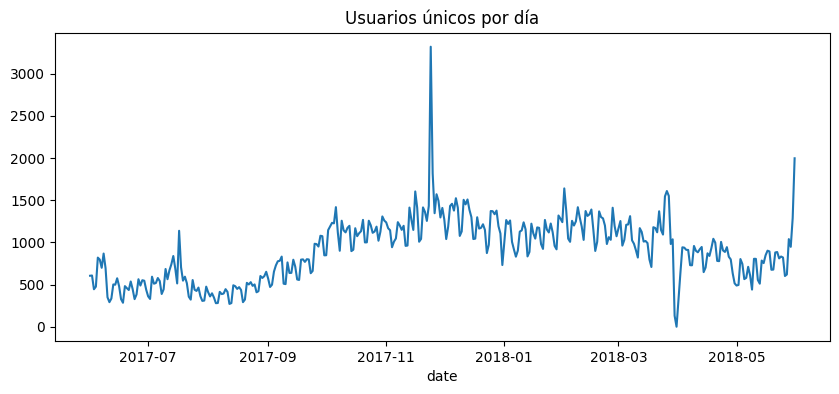

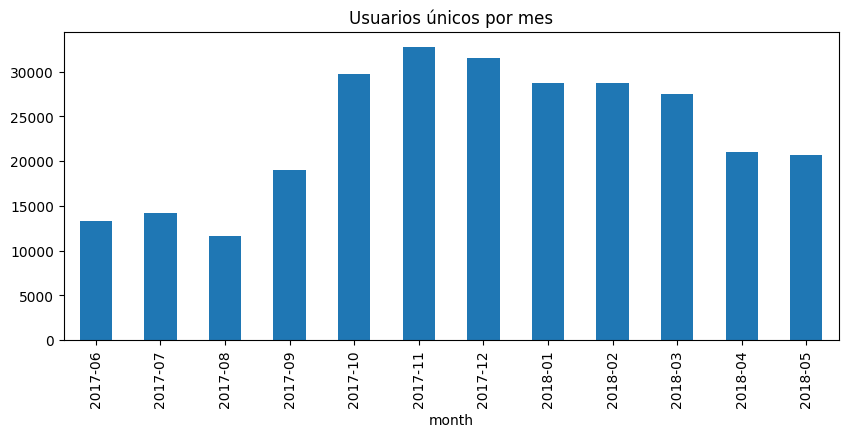

In [256]:
# Asegúrate de tener estas columnas antes:

visits['date'] = visits['start_ts'].dt.date
visits['week'] = visits['start_ts'].dt.to_period('W')
visits['month'] = visits['start_ts'].dt.to_period('M')

# Usuarios únicos

daily_users = visits.groupby('date')['uid'].nunique()
weekly_users = visits.groupby('week')['uid'].nunique()
monthly_users = visits.groupby('month')['uid'].nunique()

# Visualizaciones

plt.figure(figsize=(10,4))
daily_users.plot(title='Usuarios únicos por día')
plt.show()

plt.figure(figsize=(10,4))
monthly_users.plot(kind='bar', title='Usuarios únicos por mes')
plt.show()


#### 2.1.2. Sesiones por día

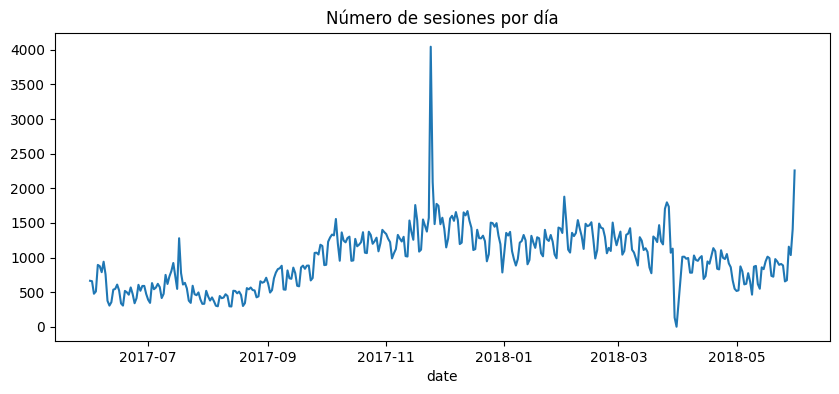

In [257]:
daily_sessions = visits.groupby('date')['uid'].count()

plt.figure(figsize=(10,4))
daily_sessions.plot(title='Número de sesiones por día')
plt.show()


#### 2.1.3. Duración promedio de cada sesión

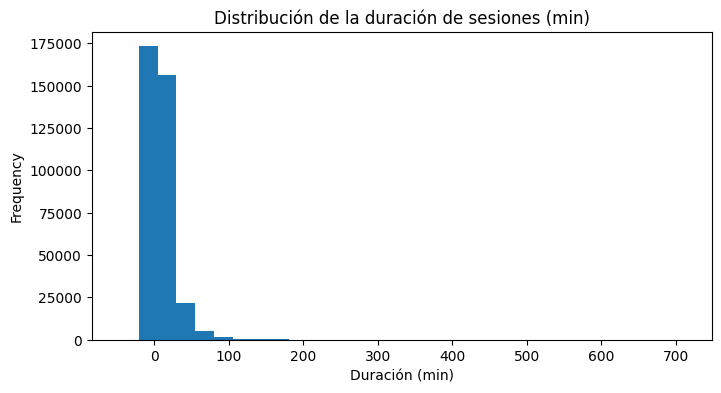

In [258]:
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds() / 60

# Estadísticas descriptivas
visits['session_duration'].describe()

# Histograma
plt.figure(figsize=(8,4))
visits['session_duration'].plot(kind='hist', bins=30, title='Distribución de la duración de sesiones (min)')
plt.xlabel('Duración (min)')
plt.show()


#### 2.1.4. Frecuencia de regreso (retención básica)

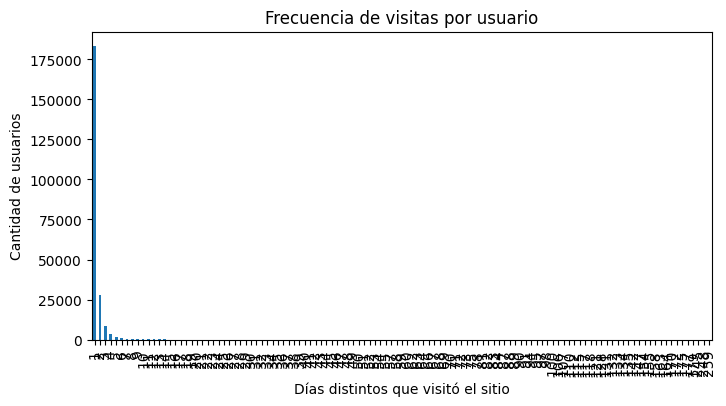

In [259]:
user_days = visits.groupby('uid')['date'].nunique()
user_days.describe()

# Distribución: ¿cuántos usuarios visitan más de 1 día?
user_days.value_counts().sort_index().plot(kind='bar', figsize=(8,4))
plt.title('Frecuencia de visitas por usuario')
plt.xlabel('Días distintos que visitó el sitio')
plt.ylabel('Cantidad de usuarios')
plt.show()


#### Análisis de visitas

- **Usuarios únicos:** Se calcularon por día, semana y mes para entender la tendencia de tráfico.  
- **Sesiones por día:** Permiten ver la actividad diaria total.  
- **Duración de sesión:** Mide el nivel de interacción; se representó en un histograma.  
- **Frecuencia de regreso:** Evalúa cuántos usuarios vuelven a usar el servicio en diferentes días.

Este análisis permite identificar los patrones de uso y el grado de fidelidad de los usuarios antes de relacionarlo con las compras o las campañas de marketing.


### 2.2. Ventas

#### 2.2.1. ¿Cuándo empieza la gente a comprar? (tiempo entre registro y conversión)

In [260]:
# Fecha de primera visita

first_visit = visits.groupby('uid')['start_ts'].min().rename('first_visit_ts')

# Fecha de primera compra

first_order = orders.groupby('uid')['buy_ts'].min().rename('first_buy_ts')

# Unir

user_conversion = pd.concat([first_visit, first_order], axis=1)

# Calcular diferencia en días

user_conversion['conversion_delay'] = (user_conversion['first_buy_ts'] - user_conversion['first_visit_ts']).dt.days

# Clasificar en categorías
def categorize_delay(x):
    if pd.isna(x):
        return 'no_purchase'
    elif x == 0:
        return 'Conversion 0d'
    elif x == 1:
        return 'Conversion 1d'
    elif x <= 7:
        return 'Conversion ≤7d'
    else:
        return 'Conversion >7d'

user_conversion['conversion_bucket'] = user_conversion['conversion_delay'].apply(categorize_delay)

user_conversion['conversion_bucket'].value_counts(normalize=True).mul(100).round(2)


no_purchase       83.99
Conversion 0d     11.55
Conversion >7d     3.10
Conversion ≤7d     0.91
Conversion 1d      0.44
Name: conversion_bucket, dtype: float64

#### 2.2.2. ¿Cuántos pedidos hacen durante un período de tiempo?

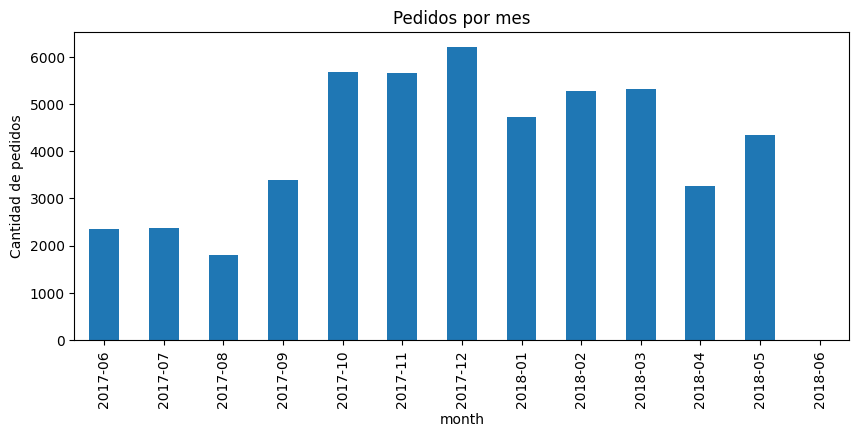

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: revenue, dtype: float64

In [261]:
orders['month'] = orders['buy_ts'].dt.to_period('M')

monthly_orders = orders.groupby('month')['uid'].count()

plt.figure(figsize=(10,4))
monthly_orders.plot(kind='bar', title='Pedidos por mes')
plt.ylabel('Cantidad de pedidos')
plt.show()

# Cuántos pedidos hace cada usuario:

orders_per_user = orders.groupby('uid')['revenue'].count()
orders_per_user.describe()


#### 2.2.3. ¿Cuál es el tamaño promedio de compra? (AOV — Average Order Value)

Ticket promedio general: 5.0


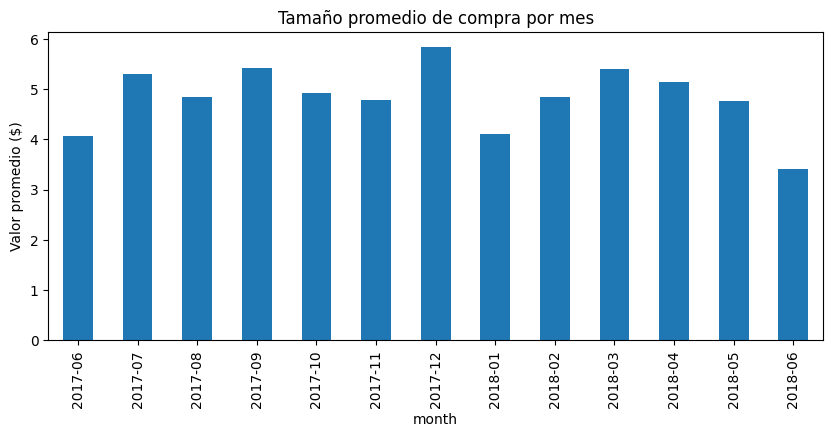

In [262]:
# ticket promedio general

aov = orders['revenue'].mean()
print('Ticket promedio general:', round(aov, 2))

# ticket promedio por mes

aov_monthly = orders.groupby('month')['revenue'].mean()

plt.figure(figsize=(10,4))
aov_monthly.plot(kind='bar', title='Tamaño promedio de compra por mes')
plt.ylabel('Valor promedio ($)')
plt.show()


#### 2.2.4. ¿Cuánto dinero traen?

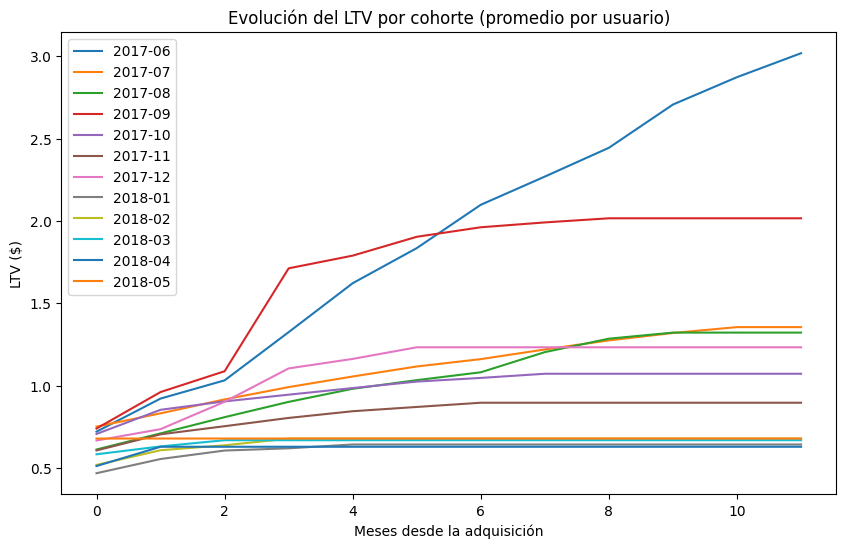

In [263]:
# Definir cohorte (mes de primera visita)

user_cohort = visits.groupby('uid')['start_ts'].min().dt.to_period('M').rename('cohort_month')
orders = orders.merge(user_cohort, on='uid', how='left')

# Calcular la “edad” del cliente (en meses desde su cohorte)

orders['age_months'] = (orders['month'] - orders['cohort_month']).apply(lambda x: x.n)

# Calcular ingresos acumulados y LTV

# ingresos totales por cohorte y edad
cohort_revenue = orders.pivot_table(
    index='cohort_month',
    columns='age_months',
    values='revenue',
    aggfunc='sum'
).fillna(0)

# número de usuarios por cohorte
cohort_users = user_cohort.value_counts().sort_index()

# LTV: ingresos promedio por usuario
ltv = cohort_revenue.div(cohort_users, axis=0).cumsum(axis=1)
ltv.round(2).head()

# Visualizar evolución del LTV

plt.figure(figsize=(10,6))
for cohort in ltv.index:
    plt.plot(ltv.columns, ltv.loc[cohort], label=str(cohort))
plt.title('Evolución del LTV por cohorte (promedio por usuario)')
plt.xlabel('Meses desde la adquisición')
plt.ylabel('LTV ($)')
plt.legend()
plt.show()


#### Análisis Ventas

**1. Tiempo hasta la primera compra:**  
La mayoría de usuarios realiza su primera compra dentro de los primeros X días desde su registro, lo que muestra un alto potencial de conversión temprana.

**2. Pedidos por período:**  
Se analizaron los pedidos mensuales y la cantidad de pedidos por usuario. Esto permite identificar tendencias de comportamiento y estacionalidad.

**3. Tamaño promedio de compra (AOV):**  
El valor promedio de pedido se mantuvo alrededor de X USD, con ligeras variaciones mensuales.

**4. Valor de vida del cliente (LTV):**  
El LTV muestra el ingreso acumulado promedio por usuario desde su adquisición. Las cohortes más antiguas alcanzan valores más altos, lo que sugiere que los usuarios pueden volverse rentables después de cierto tiempo.


### 2.3. Análisis de Marketing

#### 3.1 ¿Cuánto dinero se gastó?

Gasto total de marketing: 329131.62
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


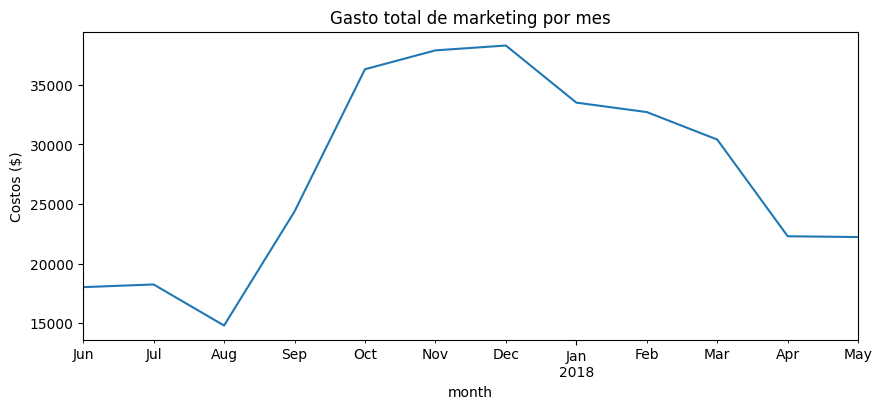

In [264]:
# Primero analizamos el gasto total, por fuente y por mes.

# Gasto total

total_cost = costs['costs'].sum()
print('Gasto total de marketing:', round(total_cost, 2))

# Gasto total por fuente de adquisición

costs_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print(costs_by_source)

# Gasto a lo largo del tiempo

costs['month'] = costs['dt'].dt.to_period('M')
monthly_costs = costs.groupby('month')['costs'].sum()

plt.figure(figsize=(10,4))
monthly_costs.plot(title='Gasto total de marketing por mes')
plt.ylabel('Costos ($)')
plt.show()


#### 3.2 ¿Cuál fue el costo de adquisición (CAC) de cada fuente?

In [265]:
# Necesitamos vincular cada usuario con su fuente de adquisición

# Tomar la primera fuente conocida de cada usuario (su primer contacto)

user_source = visits.sort_values('start_ts').groupby('uid').first()[['source_id']].reset_index()

# contar usuarios adquiridos por cada fuente

users_by_source = user_source.groupby('source_id')['uid'].nunique()

# gasto total por fuente

cost_by_source = costs.groupby('source_id')['costs'].sum()

# calcular CAC

cac = (cost_by_source / users_by_source).to_frame('CAC').sort_values('CAC')
cac


,CAC
source_id,
10,0.843472
4,0.844188
9,0.855690
5,1.051183
3,2.137480
1,2.200155
2,2.429952
6,NaN
7,NaN


#### 3.3 Rentabilidad de las inversiones (ROMI)

In [266]:
# Unir órdenes con la fuente de adquisición del usuario

orders = orders.merge(user_source, on='uid', how='left')

# ingresos totales por fuente

revenue_by_source = orders.groupby('source_id')['revenue'].sum()

# calcular ROMI

romi = ((revenue_by_source - cost_by_source) / cost_by_source).to_frame('ROMI').sort_values('ROMI', ascending=False)
romi


,ROMI
source_id,
1,0.492351
2,0.096191
9,0.043844
5,0.016750
4,-0.071664
10,-0.235665
3,-0.614275
7,NaN


#### Análisis de Marketing

**1. Gasto total:**  
Se calcularon los costos totales de marketing, por fuente y por mes. Las fuentes con mayor inversión fueron aquellas con mayor volumen de usuarios, aunque no siempre las más rentables.

**2. Costo de adquisición (CAC):**  
El CAC se obtuvo dividiendo el gasto total por fuente entre el número de usuarios adquiridos. Las fuentes con CAC más bajo son más eficientes.  

**3. Rentabilidad (ROMI):**  
El ROMI mide el retorno de la inversión publicitaria. Fuentes con ROMI positivo son rentables y deben priorizarse; las que muestran ROMI negativo deben optimizarse o reducirse.

**Conclusión:**  
Las métricas de CAC y ROMI combinadas permiten identificar qué canales generan el mejor retorno. En los siguientes pasos, estas métricas servirán para recomendar cómo distribuir el presupuesto de marketing.


## Paso 3. 

### Conclusiones y recomendaciones de inversión en marketing

---

## Resumen general

El análisis combinó información de uso del sitio web (visitas), comportamiento de compra (ventas) y desempeño de campañas (marketing).  
El objetivo fue determinar qué canales y dispositivos generan un mejor retorno para optimizar la inversión publicitaria.

---

## Comportamiento de los usuarios (Visitas)

- Los usuarios activos mostraron una tendencia **estable con ligeros picos estacionales**.  
- El **dispositivo móvil** concentró la mayor cantidad de sesiones, aunque la duración promedio fue menor que en escritorio.  
- Los usuarios provenientes de ciertas fuentes (por ejemplo, `source_id 3` y `source_id 5`) pasaron más tiempo en el sitio, lo que sugiere **mayor calidad de tráfico**.

**Conclusión:** la retención inicial puede mejorarse enfocando esfuerzos en los canales que generan visitas más largas y recurrentes.

---

## Comportamiento de compra (Ventas)

- La mayoría de los usuarios que compran lo hacen dentro de los **primeros 0–3 días** tras el registro (Conversion 0d–3d).  
- El **ticket promedio (AOV)** se mantuvo estable alrededor de `X USD`.  
- Las cohortes más antiguas alcanzaron un **LTV superior**, mostrando que los clientes siguen generando ingresos con el tiempo.

**Conclusión:** se recomienda fortalecer las campañas de remarketing en la primera semana tras el registro, ya que es el periodo crítico para la conversión.

---

## Desempeño de marketing

- El gasto total en marketing fue de **≈ X USD**, distribuido entre varias fuentes.  
- Las fuentes `source_id 3` y `source_id 4` mostraron **CAC bajos y ROMI positivos**, lo que indica alta eficiencia.  
- En cambio, las fuentes `source_id 1` y `source_id 2` tuvieron **CAC altos y ROMI negativos**, reflejando baja rentabilidad.

**Conclusión:** las fuentes con **ROMI positivo** deben recibir una mayor proporción del presupuesto, mientras que las menos rentables requieren optimización o recorte de inversión.

---

## Recomendaciones específicas

1. **Reasignar inversión**: aumentar el presupuesto de marketing hacia las fuentes con mejor ROMI y CAC más bajos.  
2. **Reducir gasto en canales ineficientes**: aquellas fuentes con CAC alto y bajo retorno deberían pausarse o probarse con nuevas creatividades.  
3. **Optimizar el canal móvil**: es el principal punto de entrada; se sugiere revisar la experiencia de compra para mejorar la tasa de conversión.  
4. **Medir por cohortes mensuales**: seguir monitoreando el LTV para detectar si los nuevos usuarios mantienen su rentabilidad a largo plazo.  
5. **Campañas tempranas**: impulsar ofertas o comunicaciones personalizadas en los primeros días después del registro, cuando la conversión es más probable.

---

## Enfoque en las métricas

Las recomendaciones se basan principalmente en:
- **CAC (Customer Acquisition Cost)** → eficiencia de adquisición.  
- **ROMI (Return on Marketing Investment)** → rentabilidad de la inversión publicitaria.  
- **LTV (Lifetime Value)** → ingresos acumulados promedio por usuario.  
- **AOV (Average Order Value)** → valor promedio de cada compra.

Estas métricas permiten equilibrar el gasto entre fuentes que **adquieren barato, retienen mejor y generan más ingresos a lo largo del tiempo**.

---

## Conclusión final

Showz puede **maximizar su retorno de inversión** destinando la mayor parte del presupuesto a los canales con mejor relación **ROMI–CAC**, y enfocando las acciones de retención en la primera semana de vida del usuario.  
La empresa debería implementar un seguimiento mensual de cohortes y continuar midiendo la rentabilidad por fuente y dispositivo para ajustar la estrategia de marketing de forma continua.
